In [1]:
# Loading all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
df = pd.read_csv('tax_returns.csv')

In [3]:
df.head()

,income_declared,work_expense_claim,travel_expense_claim,education_expense,other_deductions,total_deductions,deduction_income_ratio,prior_year_income_delta,prior_year_deduction_delta,refund_requested,filing_method,industry_code,num_dependents,fraud_label
0,73900,7230,2110,3990,2190,15520,0.2100,0.1984,0.0172,7170,self,hospitality,0,0
1,45000,5180,620,2280,1320,9400,0.2089,0.0181,-0.1499,2210,self,retail,3,0
2,92700,7160,1560,3740,2060,14520,0.1566,-0.0278,-0.1344,1910,self,hospitality,2,0
3,79100,24230,2500,1120,1120,28970,0.3662,0.1502,-0.2046,11520,self,transport,0,0
4,63800,15040,2330,3680,720,21770,0.3412,0.1701,0.1752,8470,tax_agent,construction,4,0


In [4]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

In [5]:
Y = df['fraud_label']

In [6]:
X = df.drop(columns = ['fraud_label'])

In [7]:
X = pd.get_dummies(X, columns=['filing_method', 'industry_code'])

In [8]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state = 1)

In [9]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [10]:
model = XGBClassifier()

In [11]:
model.fit(X_train,Y_train)

c:\Users\Hi\Desktop\project work\ato refund fraud project\ato_env\lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The XGBClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [12]:
Y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import classification_report, roc_auc_score

In [14]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     11537
           1       0.99      0.79      0.88       963

    accuracy                           0.98     12500
   macro avg       0.99      0.89      0.94     12500
weighted avg       0.98      0.98      0.98     12500



In [15]:
counts = Y_train.value_counts()

In [16]:
scale = counts[0] / counts[1]

In [17]:
model = XGBClassifier(scale_pos_weight = scale)

In [18]:
model.fit(X_train,Y_train)

c:\Users\Hi\Desktop\project work\ato refund fraud project\ato_env\lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The XGBClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [19]:
Y_pred_balanced = model.predict(X_test)

In [20]:
print(classification_report(Y_test, Y_pred_balanced))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99     11537
           1       0.87      0.81      0.84       963

    accuracy                           0.98     12500
   macro avg       0.93      0.90      0.91     12500
weighted avg       0.98      0.98      0.98     12500



In [21]:
roc_auc_score(Y_test, Y_pred_balanced)

0.8999571202175745

In [22]:
from sklearn.metrics import roc_curve

In [23]:
fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_balanced)

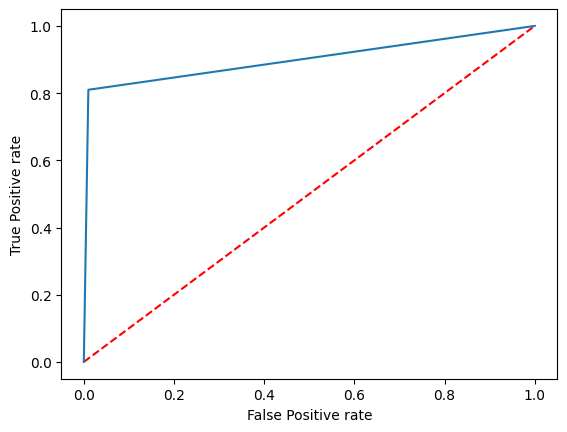

In [24]:
plt.plot([0,1], [0,1], linestyle='--', color='red', label='Random')
plt.plot(fpr,tpr)
plt.xlabel('False Positive rate')
plt.ylabel('True Positive rate')
plt.show()

In [25]:
os.makedirs('plots', exist_ok=True)

In [26]:
import shap

In [27]:
print(X_train.dtypes)

income_declared                float64
work_expense_claim             float64
travel_expense_claim           float64
education_expense              float64
other_deductions               float64
total_deductions               float64
deduction_income_ratio         float64
prior_year_income_delta        float64
prior_year_deduction_delta     float64
refund_requested               float64
num_dependents                 float64
filing_method_self             float64
filing_method_tax_agent        float64
industry_code_IT               float64
industry_code_construction     float64
industry_code_education        float64
industry_code_finance          float64
industry_code_healthcare       float64
industry_code_hospitality      float64
industry_code_manufacturing    float64
industry_code_real_estate      float64
industry_code_retail           float64
industry_code_transport        float64
dtype: object


In [28]:
explainer = shap.Explainer(model,X_train)

In [29]:
shap_values = explainer.shap_values(X_test)

 97%|=================== | 12146/12500 [00:31<00:00]       

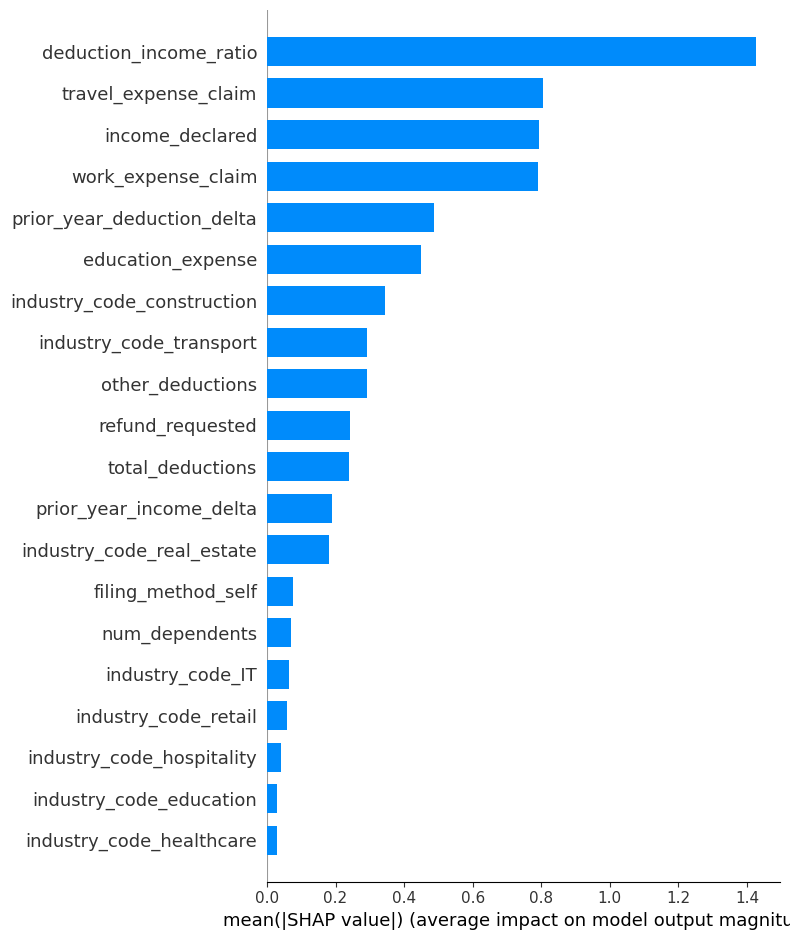

In [30]:
shap.summary_plot(shap_values, X_test,plot_type = 'bar' )

In [31]:
fraud_idx = X_test[Y_test == 1].index[0]

In [32]:
explanation = shap.Explanation(
    values=shap_values[X_test.index.get_loc(fraud_idx)],
    base_values=explainer.expected_value,
    data=X_test.loc[fraud_idx],
    feature_names=X_test.columns.tolist()
)

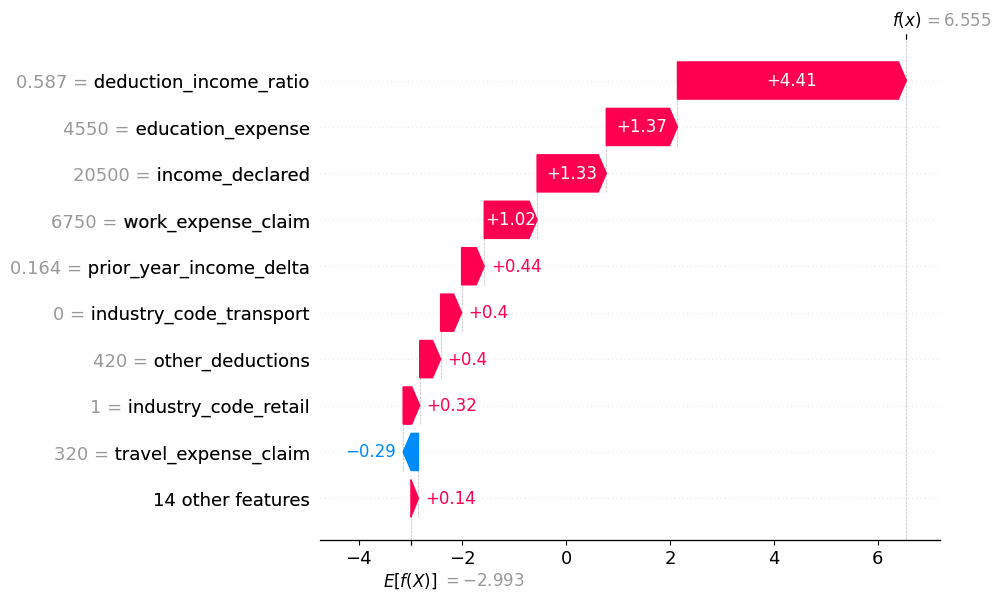

In [33]:
shap.plots.waterfall(explanation)

In [34]:
import joblib

In [35]:
os.makedirs('model', exist_ok=True)

In [36]:
explainer = shap.TreeExplainer(model)

In [37]:
joblib.dump(explainer, 'model/explainer.pkl')

['model/explainer.pkl']

In [38]:
joblib.dump(X_train.columns.tolist(), 'model/model_columns.pkl')

['model/model_columns.pkl']

In [39]:
import joblib
joblib.dump(model, 'model/xgb_fraud_model.pkl')
loaded = joblib.load('model/xgb_fraud_model.pkl')
print(loaded.predict(X_test[:5]))

[0 1 0 0 1]
